In [1]:
# Installing dependencies and setting env

In [2]:
!pip install tensorflow opencv-python matplotlib

In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip list

Package                 Version
----------------------- -----------
absl-py                 2.3.1
appnope                 0.1.4
asttokens               3.0.1
astunparse              1.6.3
certifi                 2025.11.12
charset-normalizer      3.4.4
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.19
decorator               5.2.1
executing               2.2.1
flatbuffers             25.12.19
fonttools               4.61.1
gast                    0.7.0
google-pasta            0.2.0
grpcio                  1.76.0
h5py                    3.15.1
idna                    3.11
ipykernel               7.1.0
ipython                 9.8.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.7.0
jupyter_core            5.9.1
keras                   3.13.0
kiwisolver              1.4.9
libclang                18.1.1
Markdown                3.10
markdown-it-py          4.0.0
MarkupSafe        

In [5]:
import tensorflow as tf
import os

/Users/adityaaggarwal/Image Classifier/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [6]:
# avoid OOM error by setting GPU memory consumption growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [7]:
tf.config.list_physical_devices('GPU')

[]

In [8]:
# Remove dodgy images i.e. incompatible image extensions

In [9]:
!pip install standard-imghdr

In [10]:
import cv2
import imghdr

/var/folders/2x/18q0ztt15zv4t2jhl_c_j7dh0000gn/T/ipykernel_14809/4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [11]:
data_dir = 'data'

In [12]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png'] 

In [13]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    # Skip non-directory files like .DS_Store Mac specific :(
    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)

        try:
            img = cv2.imread(image_path)
            img_type = imghdr.what(image_path)

            if img_type not in image_exts:
                print(f"Image not in allowed formats: {image_path}")
                os.remove(image_path)

        except Exception as e:
            print(f"Issue with image {image_path}: {e}")


Issue with image data/Sad People/.ipynb_checkpoints: [Errno 21] Is a directory: 'data/Sad People/.ipynb_checkpoints'


[ WARN:0@1.286] global grfmt_png.cpp:695 read_chunk chunk data is too large
libpng warning: iCCP: known incorrect sRGB profile


Issue with image data/Happy People/.ipynb_checkpoints: [Errno 21] Is a directory: 'data/Happy People/.ipynb_checkpoints'


In [14]:
# loading data

In [15]:
tf.data.Dataset

tensorflow.python.data.ops.dataset_ops.DatasetV2

In [16]:
import numpy as np
from matplotlib import pyplot as plt

In [17]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 206 files belonging to 2 classes.


In [18]:
data_iterator = data.as_numpy_iterator()
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x17cfa8e60>)

In [48]:
batch = data_iterator.next()

In [50]:
batch[0]
#images

array([[[[ 58.98828 ,  59.98828 ,  53.98828 ],
         [ 62.140625,  63.140625,  57.140625],
         [ 62.28125 ,  63.28125 ,  57.28125 ],
         ...,
         [ 90.94531 ,  87.94531 ,  80.94531 ],
         [ 88.390625,  85.390625,  78.390625],
         [ 93.53125 ,  90.53125 ,  83.53125 ]],

        [[ 58.70703 ,  59.70703 ,  53.70703 ],
         [ 65.65625 ,  66.65625 ,  60.65625 ],
         [ 62.328125,  63.328125,  57.328125],
         ...,
         [ 94.36328 ,  91.36328 ,  84.36328 ],
         [ 95.5625  ,  92.5625  ,  85.5625  ],
         [ 94.25    ,  91.25    ,  84.25    ]],

        [[ 63.785156,  64.78516 ,  58.785156],
         [ 65.      ,  66.      ,  60.      ],
         [ 65.109375,  66.109375,  60.109375],
         ...,
         [ 97.28516 ,  94.28516 ,  87.28516 ],
         [ 96.      ,  93.      ,  86.      ],
         [ 92.98828 ,  89.98828 ,  82.98828 ]],

        ...,

        [[156.9961  , 140.07812 , 120.23047 ],
         [ 72.75391 ,  66.94922 ,  47.375   ]

In [52]:
batch[1]
#labels

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0], dtype=int32)

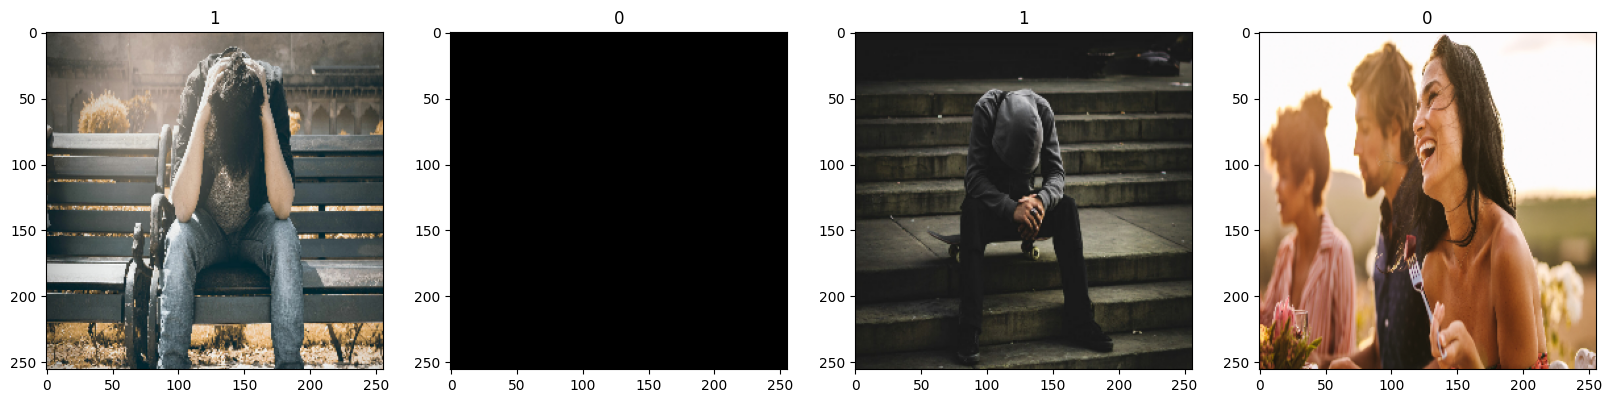

In [54]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# sad = 1 happy = 0

In [56]:
# data preprocess
data = data.map(lambda x,y: (x/255,y))

In [58]:
scaled_iterator = data.as_numpy_iterator()

In [60]:
batch = scaled_iterator.next()

2025-12-29 15:02:27.203289: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


In [64]:
batch[0].max()

1.0

In [66]:
batch[0].min()

0.0

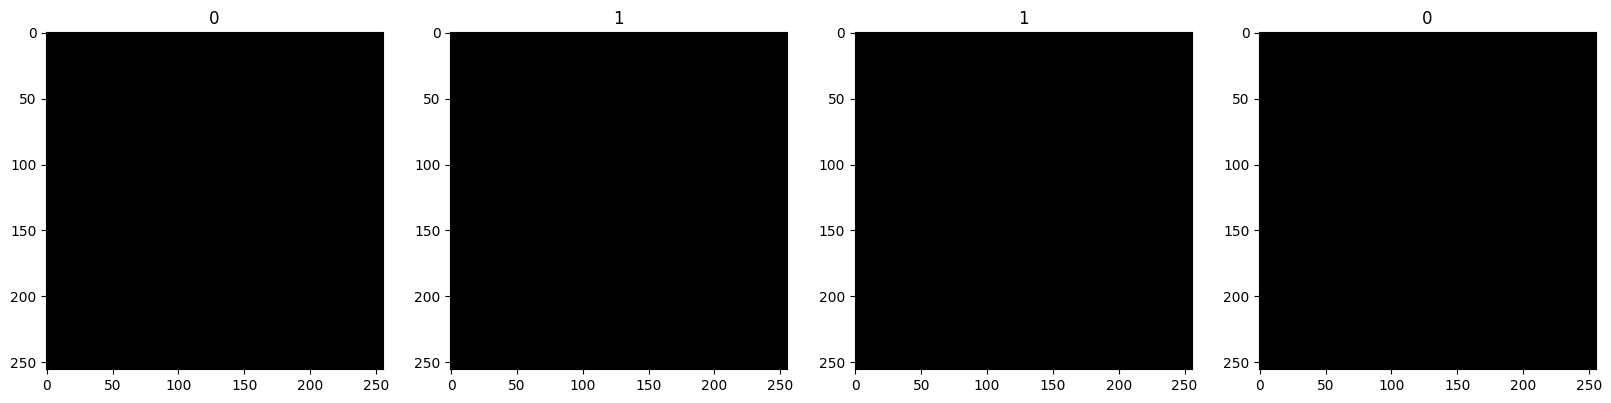

In [68]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])


In [70]:
# data partitioning 
len(data)

7

In [95]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2) + 1
test_size = int(len(data)*.1) + 1  # 0 output, so adding 1    total should be equals to 7

# training = 70% , validation set = 20 % , testing size = 10% 

In [89]:
print(train_size)
print(val_size)
print(test_size)
print(train_size + val_size + test_size, "= Data value")

4
2
1
7 = Data value


In [91]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [93]:
len(test)

1

In [115]:
#Building deep learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [117]:
model = Sequential()

In [119]:
#creating the neural network
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [121]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [123]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
#data training
#creating log directory
logdir='logs'

In [131]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [133]:
hist = model.fit(train, epochs=20, validation_data = val, callbacks = [tensorboard_callback])

Epoch 1/20


2025-12-29 19:46:24.514818: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-12-29 19:46:24.575963: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.4329 - loss: 1.5245

2025-12-29 19:46:26.177851: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-12-29 19:46:26.364652: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - accuracy: 0.4141 - loss: 1.5707 - val_accuracy: 0.5000 - val_loss: 0.6706
Epoch 2/20


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.9531 - loss: 0.1164 - val_accuracy: 0.9844 - val_loss: 0.0806
Epoch 20/20


2025-12-29 19:47:01.511982: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-12-29 19:47:01.528935: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9811 - loss: 0.1209

2025-12-29 19:47:02.665653: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-12-29 19:47:02.821433: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.9766 - loss: 0.1127 - val_accuracy: 0.9688 - val_loss: 0.0969


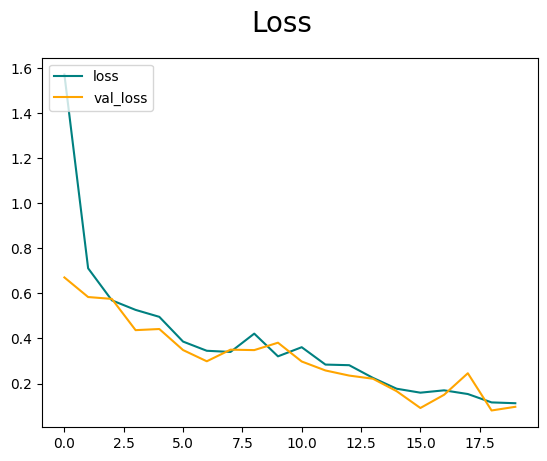

In [135]:
#plotting loss and accuracy
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

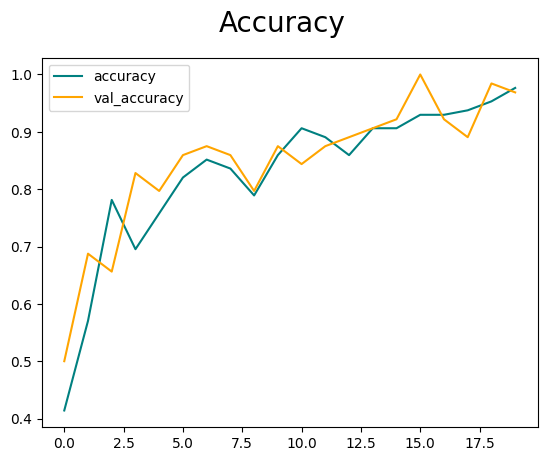

In [137]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [139]:
#model evaluation
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [141]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [143]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

2025-12-29 19:53:33.254435: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-12-29 19:53:33.275064: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


2025-12-29 19:53:33.804256: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [145]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [147]:
#model Test
import cv2

In [169]:
print(os.path.abspath('HappyTest.jpg'))

/Users/adityaaggarwal/Image Classifier/HappyTest.jpg


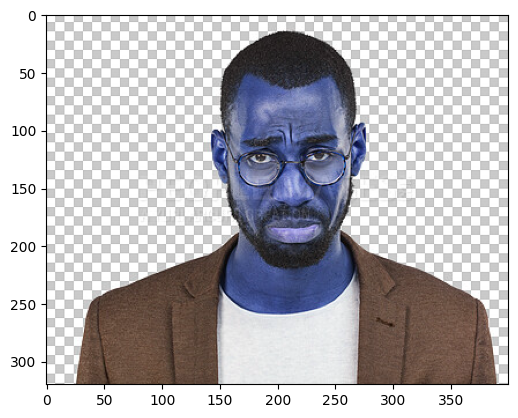

In [201]:
img = cv2.imread('sadTest.jpg')
plt.imshow(img)
plt.show()

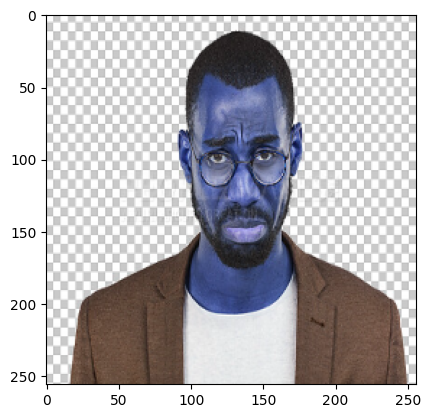

In [203]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [205]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


In [207]:
yhat

array([[0.99783856]], dtype=float32)

In [209]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


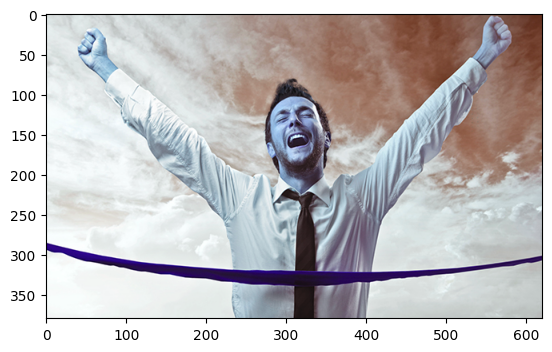

In [216]:
#happy person
img = cv2.imread('happyTest.jpg')
plt.imshow(img)
plt.show()

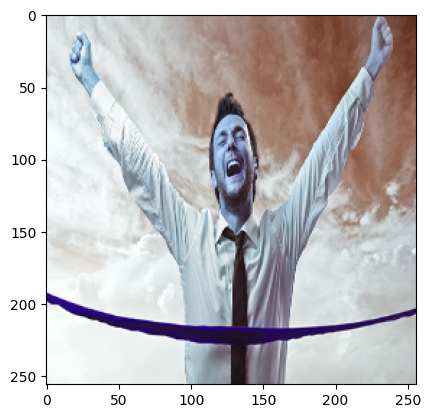

In [218]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [220]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [222]:
yhat

array([[0.23787071]], dtype=float32)

In [224]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy
